# 05 — Online serving: latency under load

**Objective.** Check that the throughput gained from concurrency (notebook 04) comes with per-request latency
that a serving system could actually offer.

**Research question.** As concurrency grows, how do time to first token (TTFT), time per output token (TPOT) and
end-to-end latency (E2E) evolve for each backend, and how much throughput can each backend deliver within a given
per-token latency budget?

**Data.** `online_points` (per-point latency statistics) and `online_requests` (every steady-state request),
campaign `online/main`.

**Method.** Latency statistics use the requests whose whole life lies inside the steady window. "p50" in the
curves is the mean over repetitions of each repetition's median; pooled p95/p99 use all steady requests of the
three repetitions and are reported only where at least 100 requests exist (`p99_meaningful`).

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "05_online_serving_latency.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = loaders.online_points()
primary = pts[pts["model"] == MODEL]

## 1. Latency vs concurrency

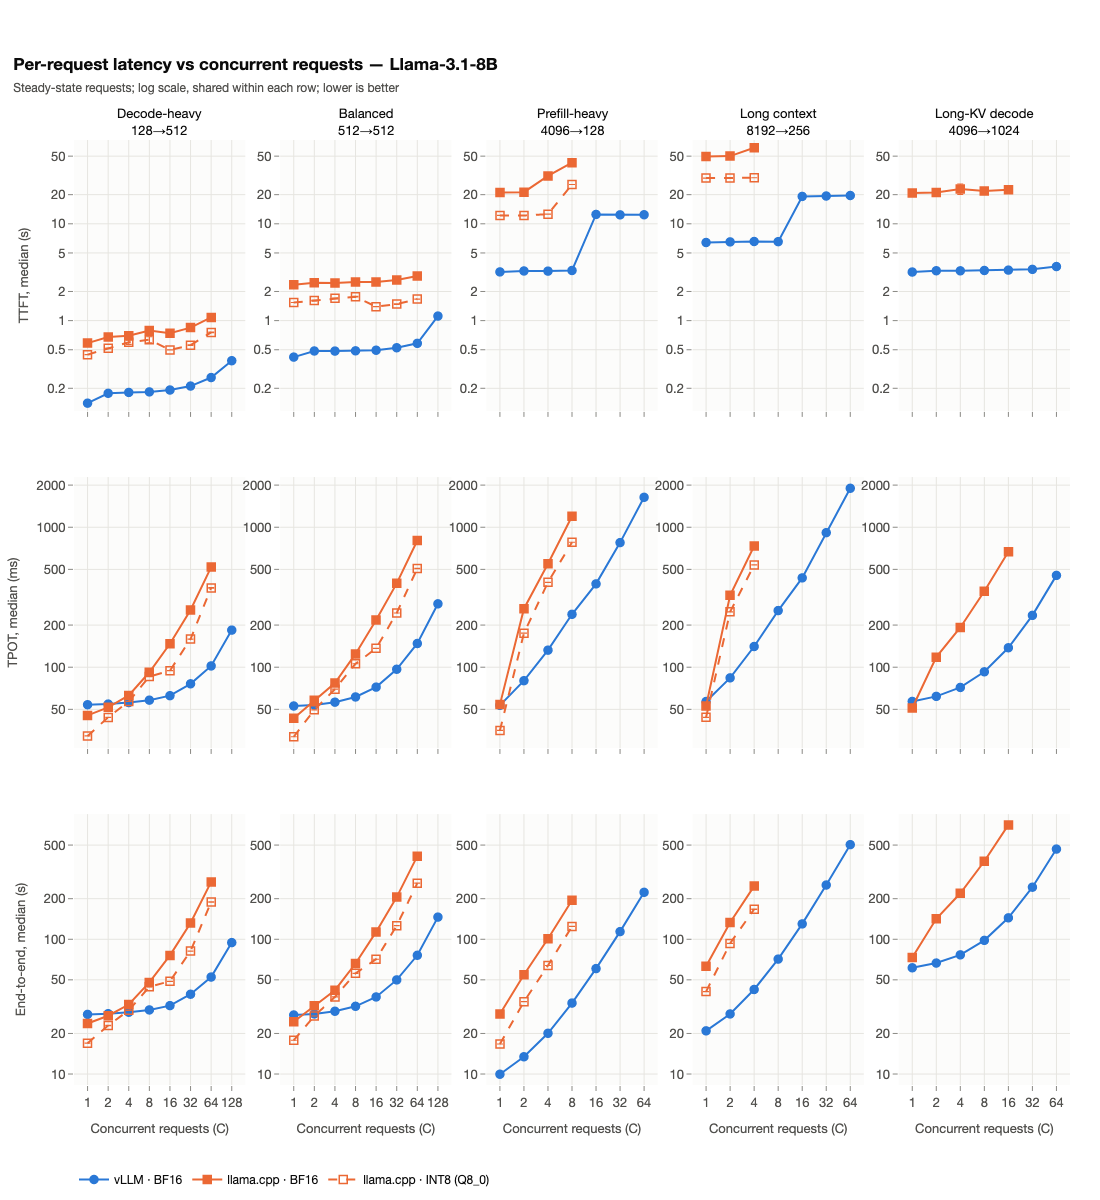

In [3]:
fig = plots.concurrency_grid(primary, [
    plots.Panel("ttft_s_p50_mean", "TTFT, median (s)", "s", log_y=True, share_y=True),
    plots.Panel("tpot_s_p50_mean", "TPOT, median (ms)", "ms", scale=1e3, log_y=True, share_y=True),
    plots.Panel("e2e_s_p50_mean", "End-to-end, median (s)", "s", log_y=True, share_y=True),
], title=f"Per-request latency vs concurrent requests — {registry.model_label(MODEL)}",
   subtitle="Steady-state requests; log scale, shared within each row; lower is better")
fig.show()

In [4]:
tp = primary[primary["precision"] == "bf16"].pivot_table(index="workload_shape", columns=["configuration_id", "concurrency"],
                                                         values="tpot_s_p50_mean", sort=False)
growth = {cid: tp[cid].iloc[:, -1] / tp[cid].iloc[:, 0] for cid in ("vllm_bf16", "llama_cpp_bf16")}
show("Median TPOT growth from C=1 to the end of each sweep: "
     f"vLLM BF16 {rng(growth['vllm_bf16'], x)}, llama.cpp BF16 {rng(growth['llama_cpp_bf16'], x)} — while vLLM's sweep "
     "covers the larger C range.")

Median TPOT growth from C=1 to the end of each sweep: vLLM BF16 3.4×–5.4×, llama.cpp BF16 11.5×–18.6× — while vLLM's sweep covers the larger C range.

**Interpretation.** vLLM's per-token latency starts higher at C = 1 but grows slowly as requests are batched;
llama.cpp's per-token latency grows roughly in proportion to C once its throughput stops growing, because the
server keeps admitting requests into ever longer steps. On the long-prompt shapes vLLM's TPOT also becomes large
at high C, consistent with new prompts' prefill chunks being scheduled between decode steps; its throughput there
is still several times llama.cpp's. TTFT behaves differently: llama.cpp's slow prefill dominates its TTFT at every
C on long prompts.

## 2. Throughput–latency trade-off

The serving-relevant question is not latency at equal C but how much throughput each backend delivers at a given
latency. Each path below walks through the measured concurrency points of one configuration.

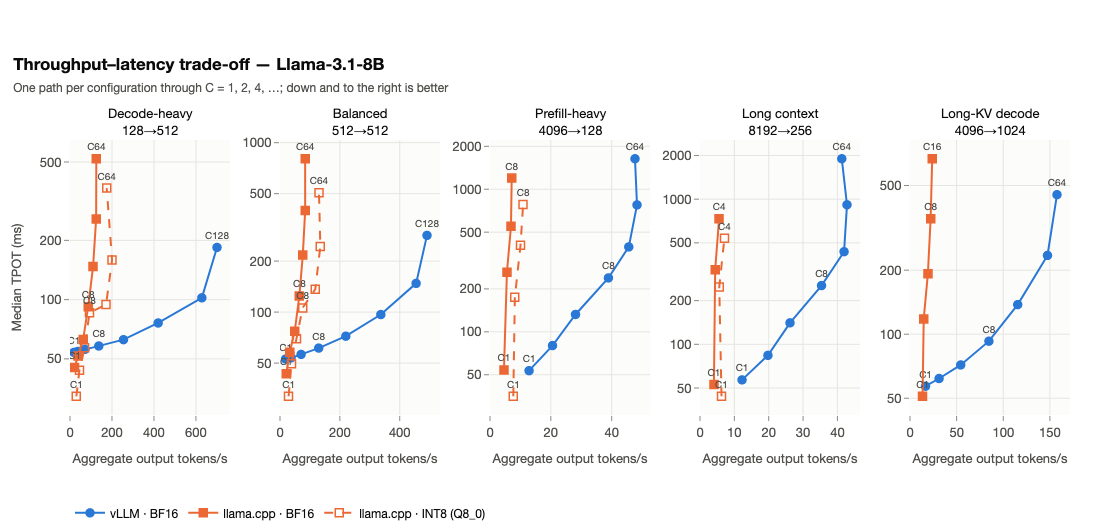

In [5]:
fig = plots.path_scatter(primary, x="output_tok_s_mean", y="tpot_s_p50_mean", y_scale=1e3,
                         x_title="Aggregate output tokens/s", y_title="Median TPOT (ms)", log_y=True,
                         title=f"Throughput–latency trade-off — {registry.model_label(MODEL)}",
                         subtitle="One path per configuration through C = 1, 2, 4, …; down and to the right is better",
                         label_cs=(1, 8))
fig.show()
export_figure(fig, "latency_throughput_tradeoff", source=NOTEBOOK,
              caption="Median TPOT vs aggregate output tokens/s across concurrency (8B), one path per configuration.")

In [6]:
budgets = pd.concat([metrics.throughput_under_latency_budget(pts, b) for b in (0.1, 0.2)])
view = budgets[budgets["model"] == MODEL].assign(
    configuration=lambda d: d["configuration_id"].map(registry.configuration_label),
    workload=lambda d: d["workload"].map(lambda w: registry.workload_label(w, short=True)),
    budget=lambda d: (d["budget_s"] * 1e3).astype(int).astype(str) + " ms")
wide = view.pivot_table(index=["workload", "configuration"], columns="budget", values=["throughput", "concurrency"],
                        sort=False)
wide.columns = [f"{'Output tok/s' if a == 'throughput' else 'at C'} (TPOT ≤ {b})" for a, b in wide.columns]
display(table(wide.reset_index().rename(columns={"workload": "Workload", "configuration": "Configuration"}),
              {c: ("{:,.0f}" if c.startswith("Output") else "{:.0f}") for c in wide.columns},
              caption="Highest measured throughput whose median TPOT stays within the budget"))
bb = budgets.merge(registry.configurations_frame()[["configuration_id", "backend", "precision"]], on="configuration_id")
r = bb[(bb["budget_s"] == 0.1) & (bb["precision"] == "bf16")].pivot_table(index=["model", "workload"], columns="backend",
                                                                         values="throughput").dropna()
show(f"Within a 100 ms median TPOT budget, vLLM BF16 delivers {rng(r['vllm'] / r['llama_cpp'], x)} the output throughput "
     f"of llama.cpp BF16 across the {len(r)} (model, workload) pairs where both meet the budget.")

Workload,Configuration,Output tok/s (TPOT ≤ 100 ms),Output tok/s (TPOT ≤ 200 ms),at C (TPOT ≤ 100 ms),at C (TPOT ≤ 200 ms)
128→512,vLLM · BF16,420,700,32,128
128→512,llama.cpp · BF16,87,110,8,16
128→512,llama.cpp · INT8 (Q8_0),172,200,16,32
512→512,vLLM · BF16,337,455,32,64
512→512,llama.cpp · BF16,49,65,4,8
512→512,llama.cpp · INT8 (Q8_0),55,118,4,16
4096→128,vLLM · BF16,21,28,2,4
4096→128,llama.cpp · BF16,5,5,1,1
4096→128,llama.cpp · INT8 (Q8_0),8,8,1,2
8192→256,vLLM · BF16,20,26,2,4


Within a 100 ms median TPOT budget, vLLM BF16 delivers 4.5×–9.7× the output throughput of llama.cpp BF16 across the 8 (model, workload) pairs where both meet the budget.

**Interpretation.** At any per-token latency budget that both backends can meet, vLLM delivers several times
more aggregate throughput, because it reaches the same latency at much higher concurrency. llama.cpp's best
*latency* is better (C = 1), but its throughput at that latency is low; its best *throughput* comes with
per-token latencies that grow steeply.

## 3. Tail latency and request-level distributions

In [7]:
sel = primary[(primary["precision"] == "bf16") & primary["p99_meaningful"].astype(bool)]
tail = sel[sel["concurrency"].isin([16, 32, 64])][["workload_shape", "configuration_label", "concurrency", "latency_n",
                                                    "tpot_s_pooled_p50", "tpot_s_pooled_p99", "e2e_s_pooled_p95"]]
tail = tail.assign(tpot_s_pooled_p50=tail["tpot_s_pooled_p50"] * 1e3, tpot_s_pooled_p99=tail["tpot_s_pooled_p99"] * 1e3)
display(table(tail.rename(columns={"workload_shape": "Workload", "configuration_label": "Configuration", "concurrency": "C",
                                   "latency_n": "Steady requests", "tpot_s_pooled_p50": "TPOT p50 (ms)",
                                   "tpot_s_pooled_p99": "TPOT p99 (ms)", "e2e_s_pooled_p95": "E2E p95 (s)"}),
              {"TPOT p50 (ms)": "{:.0f}", "TPOT p99 (ms)": "{:.0f}", "E2E p95 (s)": "{:.0f}"},
              caption="Pooled tail latency (BF16 pair, points with ≥ 100 steady requests)"))

Workload,Configuration,C,Steady requests,TPOT p50 (ms),TPOT p99 (ms),E2E p95 (s)
128→512,vLLM · BF16,32,102,77,77,39
128→512,vLLM · BF16,64,198,102,102,53
128→512,llama.cpp · BF16,32,102,257,257,132
128→512,llama.cpp · BF16,64,121,519,521,267
512→512,vLLM · BF16,32,102,97,98,50
512→512,vLLM · BF16,64,198,148,148,76
512→512,llama.cpp · BF16,32,102,397,398,206
512→512,llama.cpp · BF16,64,198,804,805,414
4096→128,vLLM · BF16,32,102,777,871,117
4096→128,vLLM · BF16,64,198,1636,1730,227


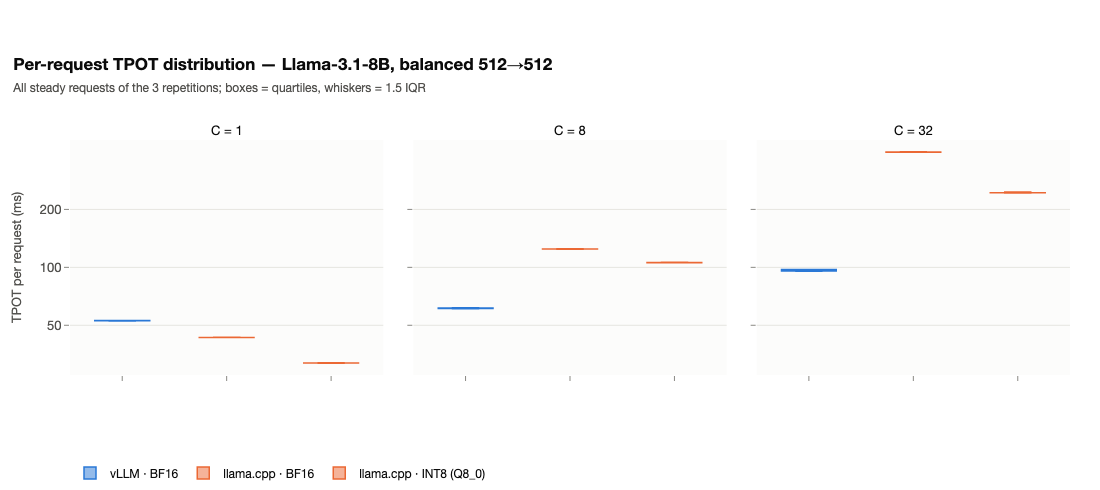

In [8]:
req = loaders.online_requests(model=MODEL)
req = req[(req["workload"] == "balanced") & req["concurrency"].isin([1, 8, 32])]
fig = plots.request_distribution(req, metric="tpot_s", scale=1e3, y_title="TPOT per request (ms)",
                                 title=f"Per-request TPOT distribution — {registry.model_label(MODEL)}, balanced 512→512",
                                 subtitle="All steady requests of the 3 repetitions; boxes = quartiles, whiskers = 1.5 IQR")
fig.show()

**Interpretation.** Per-request TPOT distributions are narrow for both backends: the closed loop with fixed
output length produces regular steps, and tails stay close to the median. The difference between the backends
is the level of the distribution at a given C, not its width.

## Conclusions

- **Measured:** vLLM's per-token latency grows slowly with concurrency; llama.cpp's grows steeply once its
  throughput saturates. Under a fixed per-token latency budget vLLM delivers several times more throughput.
- **Interpretation:** vLLM's throughput gains are usable serving capacity, not bought with unusable latency.
- **Implication for the thesis:** online experiments can run vLLM at high concurrency while keeping latency
  within plausible service levels, so concurrency-driven memory experiments remain representative of serving.

## Limitations

- The load is a closed loop with fixed ISL/OSL; open-loop arrivals with variable lengths would add queueing
  effects that are not measured here.
- Latency budgets of 100/200 ms are illustrative, not service-level objectives defined by the thesis.